## Plotting **Topic Labesls** embeddings with tSNE in 2D

In [1]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# %%
# ## Define Topic Labels
TOPIC_LABELS = {
    0: "Appointment Availability & Access",
    1: "Online Services",
    2: "Admin Processes",
    3: "Facilities & Cleanliness",
    4: "Prescription & Medication Management",
    5: "Clinical Treatment Quality",
    6: "Test Results & Follow-up",
    7: "Health Promotion",
    8: "Nursing & HCA Services",
    9: "Reception Staff Interactions",
    10: "Clinical Staff Profesionalism & Attitude",
    11: "Continuity of Care",
    12: "Privacy & Confidentiality",
    13: "Feedback & Complaints Process",
    14: "Overall Experience",
}

Generating embeddings...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Created 384-dimensional embeddings for 15 topics
Applying t-SNE...


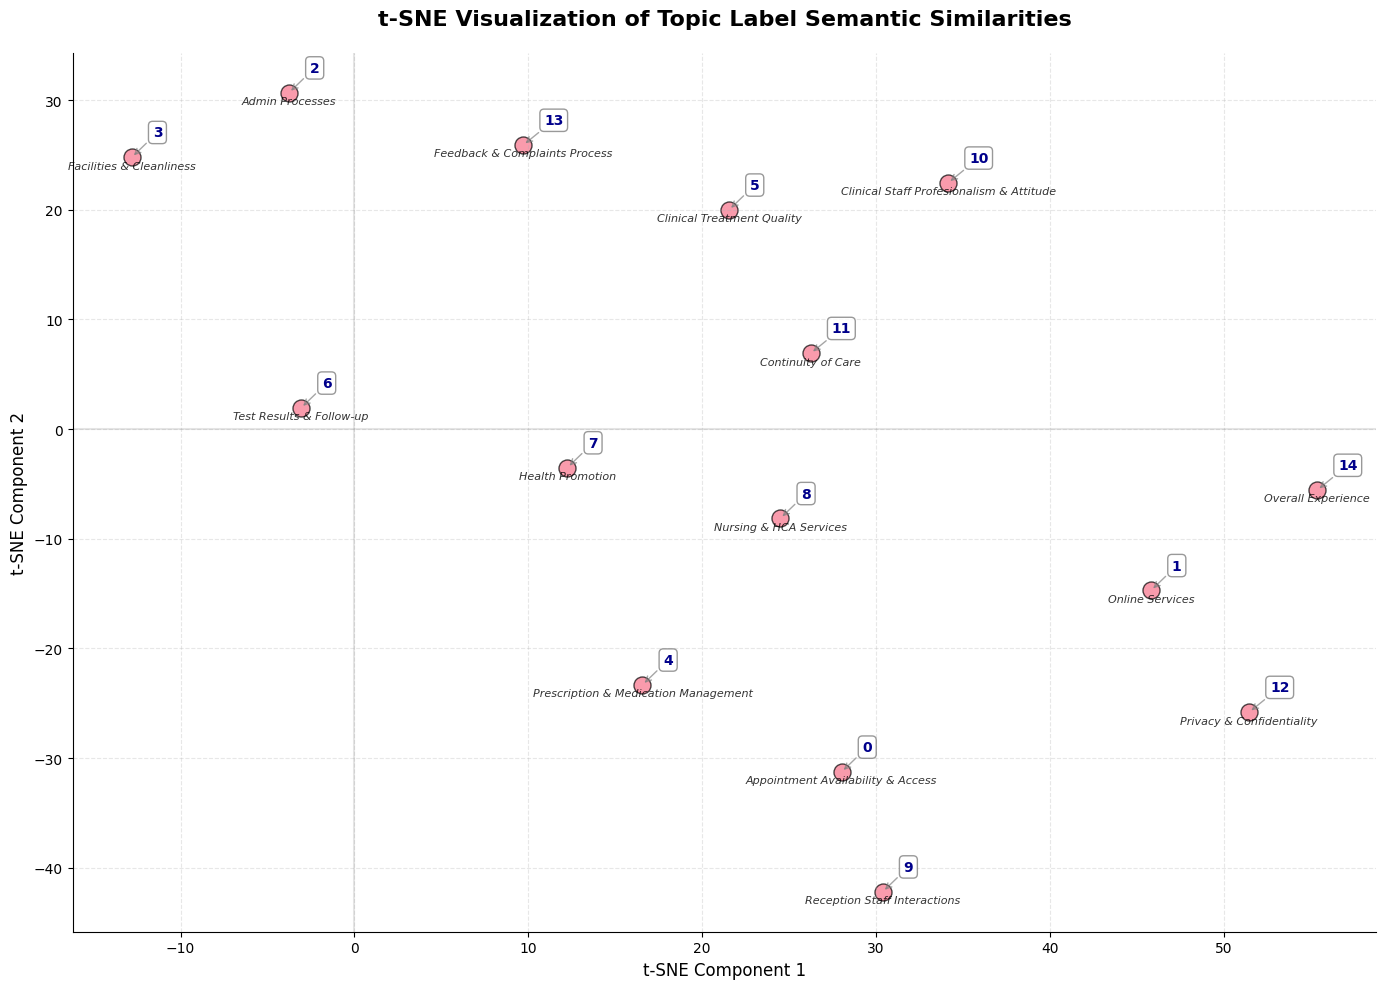


Topic coordinates in t-SNE space:
Topic 0: (28.023, -31.258)
Topic 1: (45.825, -14.702)
Topic 2: (-3.766, 30.676)
Topic 3: (-12.807, 24.787)
Topic 4: (16.566, -23.317)
Topic 5: (21.547, 19.994)
Topic 6: (-3.070, 1.938)
Topic 7: (12.251, -3.506)
Topic 8: (24.499, -8.134)
Topic 9: (30.389, -42.182)
Topic 10: (34.151, 22.455)
Topic 11: (26.249, 6.918)
Topic 12: (51.464, -25.811)
Topic 13: (9.708, 25.899)
Topic 14: (55.378, -5.559)


In [3]:
# Extract just the text labels
topic_texts = list(TOPIC_LABELS.values())
topic_ids = list(TOPIC_LABELS.keys())

# %%
# ## Generate Embeddings
# Using a lightweight but effective sentence transformer model
# The model will be downloaded automatically on first run
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Generating embeddings...")
embeddings = model.encode(topic_texts, show_progress_bar=True)
print(f"Created {embeddings.shape[1]}-dimensional embeddings for {embeddings.shape[0]} topics")

# %%
# ## Apply t-SNE Dimensionality Reduction
# perplexity is set low because we have a small dataset (n_samples < 30)
tsne = TSNE(
    n_components=2,
    perplexity=5,  # Good for small datasets (perplexity < n_samples/3)
    random_state=42,
    init='pca',
    learning_rate='auto',
    max_iter=1000
)

print("Applying t-SNE...")
embeddings_2d = tsne.fit_transform(embeddings)

# %%
# ## Create Plot
# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create DataFrame for easier plotting
df_plot = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'label': topic_texts,
    'topic_id': topic_ids
})

# Create the figure
plt.figure(figsize=(14, 10))

# Plot points
scatter = sns.scatterplot(
    data=df_plot,
    x='x',
    y='y',
    s=150,
    alpha=0.7,
    edgecolor='black',
    linewidth=1
)

# Add topic ID labels with arrows pointing to each point
for idx, row in df_plot.iterrows():
    # Add topic ID number
    plt.annotate(
        f"{row['topic_id']}",
        (row['x'], row['y']),
        xytext=(15, 15),
        textcoords='offset points',
        fontsize=10,
        weight='bold',
        color='darkblue',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='gray'),
        arrowprops=dict(arrowstyle='->', color='gray', alpha=0.7)
    )

# Add topic text labels (smaller font, no arrows)
for idx, row in df_plot.iterrows():
    plt.text(
        row['x'],
        row['y'] - 0.3,
        row['label'],
        fontsize=8,
        ha='center',
        va='top',
        alpha=0.8,
        style='italic'
    )

# Styling
plt.title('t-SNE Visualization of Topic Label Semantic Similarities', fontsize=16, weight='bold', pad=20)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.axhline(y=0, color='gray', linestyle='-', alpha=0.2)
plt.axvline(x=0, color='gray', linestyle='-', alpha=0.2)

# Remove spines
sns.despine()

plt.tight_layout()
plt.show()

# %%
# ## Optional: Print coordinates for reference
print("\nTopic coordinates in t-SNE space:")
for idx, row in df_plot.iterrows():
    print(f"Topic {row['topic_id']}: ({row['x']:.3f}, {row['y']:.3f})")